In [1]:
import pandas as pd
import glob
import csky as cy
from csky.utils import Arrays
import matplotlib.pyplot as plt
import histlite as hl
from pathlib import Path
import math
import re
import json
import os
import numpy as np
import sys
sys.path.append(os.path.abspath("../../../")) 
from matplotlib.ticker import LogLocator, NullFormatter
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
from kingmaker_fork.likelihood_analysis.utils.trial_runner_config_loading import restore_king_trial_runner
from kingmaker_fork.likelihood_analysis.utils.parallel_king_trials import get_many_fits_from_trials
from kingmaker_fork.likelihood_analysis.analysis_helpers.to_jsonable import to_jsonable


from csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu

In [2]:
timer = cy.timing.Timer()
time = timer.time

## Load cached Analysis

In [3]:
repo_cache = cy.utils.ensure_dir('/data/user/fkrafft/csky_repo')
repo = cy.selections.Repository(
    local_root= repo_cache,
    remote_root= '/data/ana/PointSource/GFU/online_v001-p10')

ana_dir = cy.utils.ensure_dir('/data/user/fkrafft/csky_gfu_tests')
with time('ana setup (from cache-to-disk)'):
    ana = cy.get_analysis(repo, 'version-001-p09' , custom_gfu.gfu_11yr, dir = ana_dir)

Setting up Analysis for:
GFU_2011_2022
Setting up GFU_2011_2022...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2023_MC.npy ...


Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2022_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2022_data.npy ...
<- /data/user/fkrafft/csky_gfu_tests/GFU_2011_2022.subanalysis.version-001-p09.npy    
Done.

0:00:46.190973 elapsed.


## Load Background Trials

In [4]:
file_identifier = 'min_count_200_coarse_angErr'
input_dir = f"/data/user/fkrafft/csky_king_tests/{file_identifier}"
plot_dir = f"/data/user/fkrafft/csky_king_tests/{file_identifier}/plots"
target_N = 1000

In [5]:

os.makedirs(plot_dir, exist_ok=True)

files = glob.glob(os.path.join(input_dir, "*.npy"))


<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3603871/424463145.py:70: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("$\sin{\delta}$" + f" = {sin_dec:.2f}")


NOTE: Using cached King parameters...


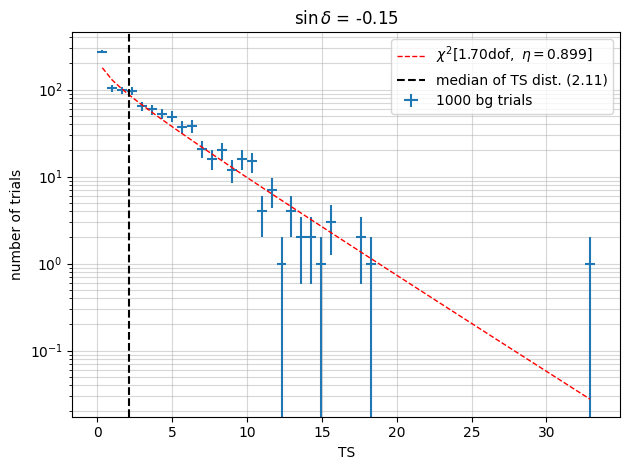

NOTE: Using cached King parameters...


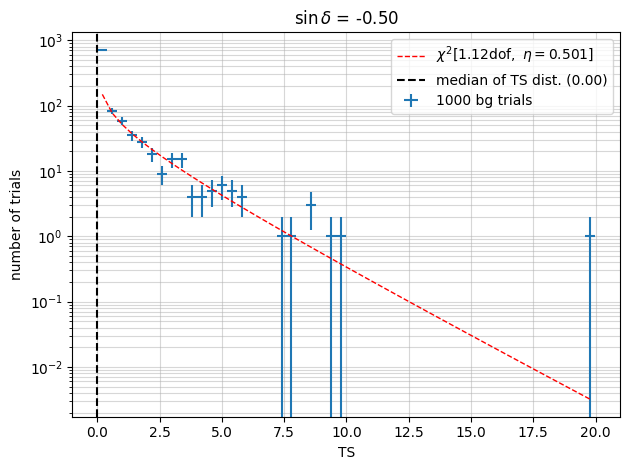

NOTE: Using cached King parameters...


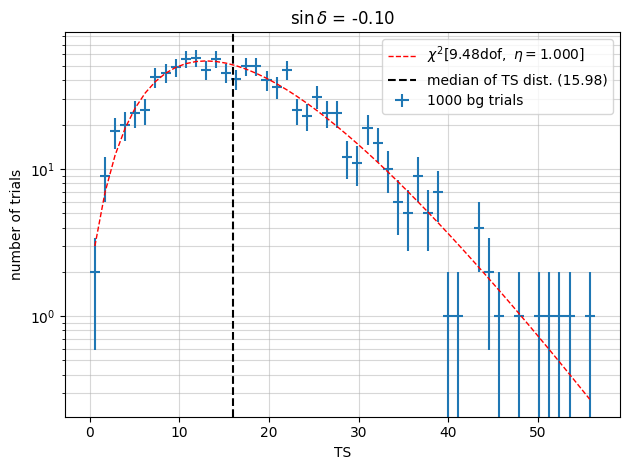

NOTE: Using cached King parameters...


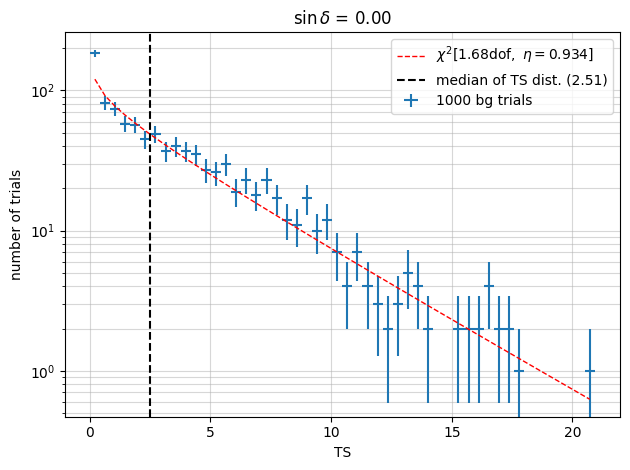

NOTE: Using cached King parameters...


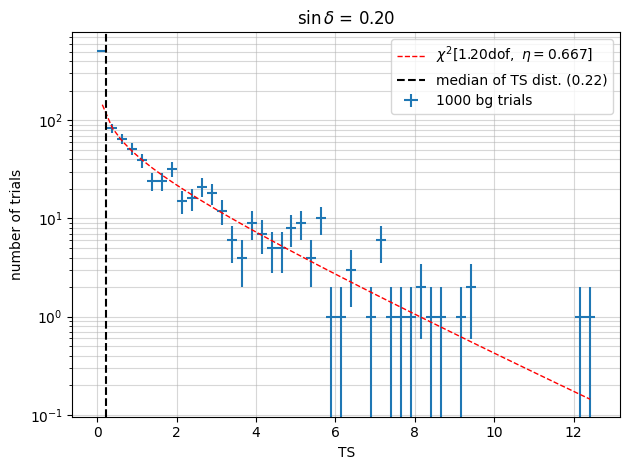

NOTE: Using cached King parameters...


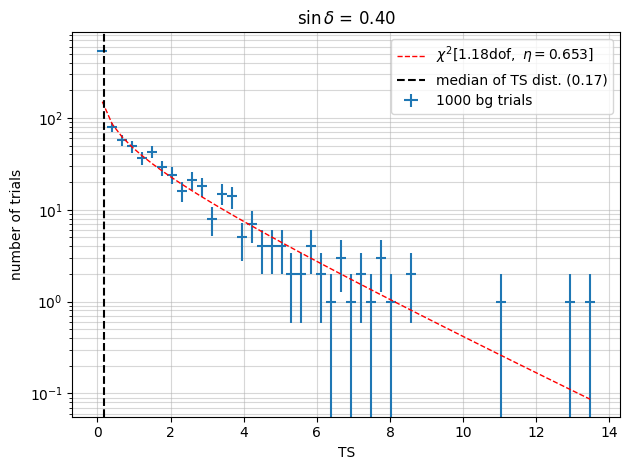

NOTE: Using cached King parameters...


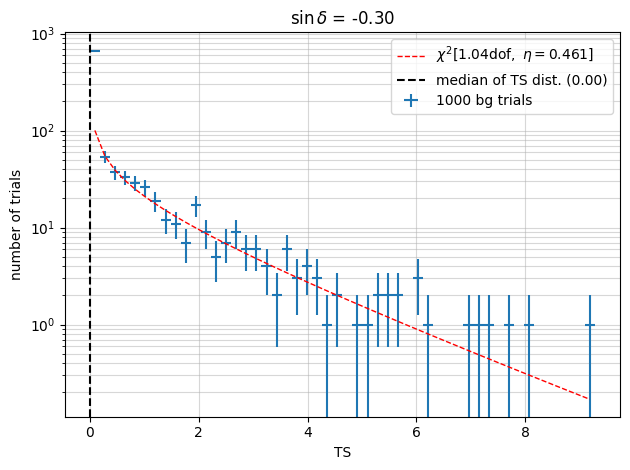

NOTE: Using cached King parameters...


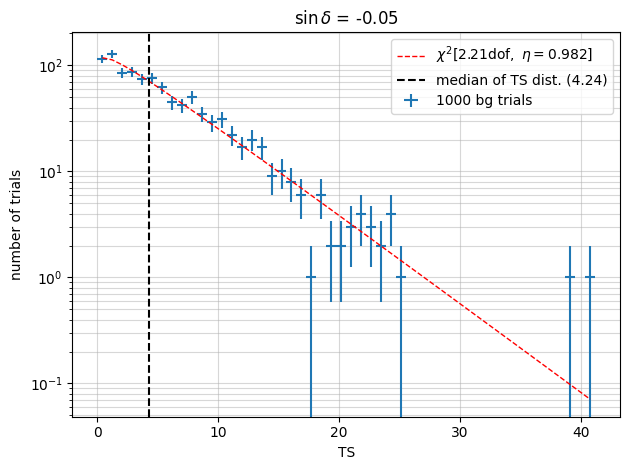

Saved plots to: /data/user/fkrafft/csky_king_tests/min_count_200_coarse_angErr/plots


In [6]:
plotting = True
data_dict = {}

for f in files:

    basename = os.path.basename(f)

    match = re.search(
        r"sindec_([-+]?\d*\.?\d+).*?N_(\d+)",
        basename
    )

    if not match:
        continue

    sin_dec = float(match.group(1))
    N = int(match.group(2))

    # skip files with wrong N
    if N != target_N:
        continue
    

    sin_dec = float(match.group(1))
    src = cy.sources(0, np.arcsin(sin_dec), deg = False)
    tr, _, _, _ = restore_king_trial_runner(
        config_path=  os.path.join(input_dir, f"king_trial_runner_config_sindec_{sin_dec}_{file_identifier}.pkl"),
        ana = ana
        )
    arr = np.load(f)

    df = pd.DataFrame(arr)          # optional
    cached_trials = cy.utils.Arrays(arr)
    #apply fits
    bg = cy.dists.Chi2TSD(cached_trials)

    data_dict[sin_dec] = {
        "df": df,
        "cached_trials": cached_trials,
        "bg": bg,
        "tr": tr
    }
    if np.sum(cached_trials["ts"] > 0) == 0:
        continue
    if plotting: 
        fig, ax = plt.subplots()

        h = bg.get_hist(bins= 50)
        hl.plot1d(
            ax,
            h,
            crosses=True,
            label=f"{bg.n_total} bg trials"
        )

        x = h.centers[0]
        norm = h.integrate().values
        ax.grid(which = 'both', alpha = 0.5)
        ax.semilogy(
            x,
            norm * bg.pdf(x),
            lw=1,
            ls="--",
            color = 'red',
            label=rf"$\chi^2[{bg.ndof:.2f}\mathrm{{dof}},\ \eta={bg.eta:.3f}]$"
        )
        ax.axvline(bg.median(), color = 'black', linestyle = 'dashed', label = f'median of TS dist. ({bg.median():.2f})')
        ax.set_xlabel("TS")
        ax.set_ylabel("number of trials")
        ax.set_title("$\sin{\delta}$" + f" = {sin_dec:.2f}")
        ax.legend()
        plt.tight_layout()

        outpath = os.path.join(plot_dir, f"bkg_trials_sin_dec_{sin_dec:.2f}.png")
        fig.savefig(outpath, dpi=200)
        plt.show()
        plt.close(fig)

print(f"Saved plots to: {plot_dir}")

In [7]:
for sin_dec, data in data_dict.items():
    print(f"{sin_dec}:\t {data['bg']}")

-0.15:	 Chi2TSD(1000 trials, eta=0.899, ndof=1.704, median=2.113 (from fit 1.843))
-0.5:	 Chi2TSD(1000 trials, eta=0.501, ndof=1.119, median=0.000 (from fit 0.000))
-0.1:	 Chi2TSD(1000 trials, eta=1.000, ndof=9.484, median=15.983 (from fit 15.778))
0.0:	 Chi2TSD(1000 trials, eta=0.934, ndof=1.677, median=2.508 (from fit 2.175))
0.2:	 Chi2TSD(1000 trials, eta=0.667, ndof=1.196, median=0.223 (from fit 0.209))
0.4:	 Chi2TSD(1000 trials, eta=0.653, ndof=1.181, median=0.174 (from fit 0.177))
-0.3:	 Chi2TSD(1000 trials, eta=0.461, ndof=1.038, median=0.000 (from fit 0.000))
-0.05:	 Chi2TSD(1000 trials, eta=0.982, ndof=2.210, median=4.236 (from fit 3.963))


<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3603871/2962883655.py:19: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("$\chi^2$ fits for different $\sin{\delta}$")
/tmp/ipykernel_3603871/2962883655.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.legend(title="$\sin{\delta}$", ncol=2, fontsize=8)


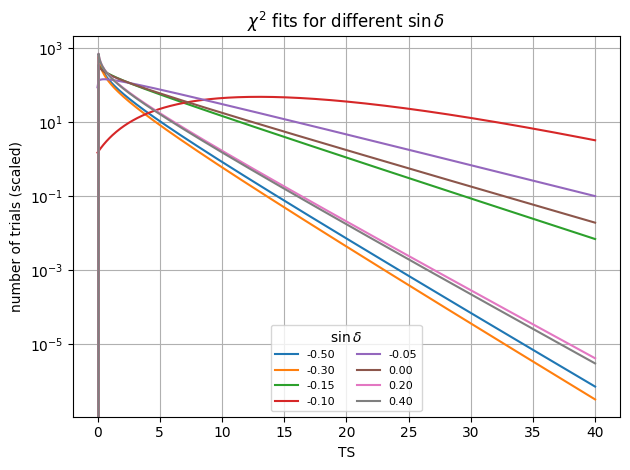

log


In [8]:
fig, ax = plt.subplots()

x = np.linspace(0, 40, 500)

for sin_dec, d in sorted(data_dict.items()):
    bg = d["bg"]

    # normalize like before
    norm = bg.n_total  # or use consistent normalization if preferred

    ax.semilogy(
        x,
        norm * bg.pdf(x),
        label=f"{sin_dec:.2f}"
    )

ax.set_xlabel("TS")
ax.set_ylabel("number of trials (scaled)")
ax.set_title("$\chi^2$ fits for different $\sin{\delta}$")
ax.legend(title="$\sin{\delta}$", ncol=2, fontsize=8)
ax.set_yscale("log")

# Major ticks (10^n)
ax.yaxis.set_major_locator(LogLocator(base=10))

# Minor ticks (2–9 within each decade)
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

# Grid styling
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "summary_chi2.png"), dpi=200)
plt.show()
plt.close(fig)
print(ax.get_yscale())

## Estimate Sensitivity + Discovery Potential

In [9]:
for sin_dec, d in sorted(data_dict.items()):
    trial_runner: cy.trial.TrialRunner = d["tr"]
    bkg = d["bg"]
    with time('ps sensitivity'):
        print(f'Estimating sensitivity for sin(dec) = {sin_dec}')
        sens = trial_runner.find_n_sig(
            # ts, threshold
            bkg.median(), # p = 50%
            # beta, fraction of trials which should exceed the threshold
            0.9, # beta = 90%
            # n_inj step size for initial scan
            n_sig_step=1,
            # this many trials at a time
            batch_size=500,
            # tolerance, as estimated relative error
            tol=.05,
            mp_cpus = 32
        )
        d["sens"] = sens

Estimating sensitivity for sin(dec) = -0.5
Start time: 2026-05-26 03:21:14.434000
Using 32 cores.
* Starting initial scan for 90% of 50 trials with TS >= 0.000...
  n_sig = 1.000 ... frac = 0.78000
  n_sig = 2.000 ... frac = 0.86000
  n_sig = 3.000 ... frac = 0.84000
  n_sig = 4.000 ... frac = 0.96000
* Generating batches of 500 trials...
n_trials | n_inj    2.00    3.20    4.40    5.60    6.80    8.00  |  n_sig(relative error)
500      |         77.2%   85.6%   93.0%   95.6%   96.8%   99.2%  |      3.908 (+/-  4.2%) [chi2.cdf]
End time: 2026-05-26 03:25:50.767072
Elapsed time: 0:04:36.333072

0:04:36.333864 elapsed.
Estimating sensitivity for sin(dec) = -0.3
Start time: 2026-05-26 03:25:50.767915
Using 32 cores.
* Starting initial scan for 90% of 50 trials with TS >= 0.000...
  n_sig = 1.000 ... frac = 0.80000
  n_sig = 2.000 ... frac = 0.86000
  n_sig = 3.000 ... frac = 0.88000
  n_sig = 4.000 ... frac = 0.98000
* Generating batches of 500 trials...
n_trials | n_inj    2.00    3.20  

In [10]:
sens_dict = {k: v["sens"] for k, v in data_dict.items()}

store data 

In [13]:
json_sens_dict = to_jsonable(sens_dict)
with open(os.path.join(plot_dir, 'king_sensitivity.json'), "w") as f:
    json.dump(json_sens_dict, f)

In [9]:
with open(os.path.join(plot_dir, 'king_sensitivity.json')) as f:
    json_sens_dict = json.load(f, parse_int = float)
    json_sens_dict = {float(k): v for k, v in json_sens_dict.items()}

In [10]:
with open(os.path.join('/data/user/fkrafft/csky_gfu_tests/trials_100k_post2018/plots', 'sensitivity.json')) as f:
    rayleigh_sens_dict = json.load(f, parse_int = float)
    rayleigh_sens_dict = {float(k): v for k, v in rayleigh_sens_dict.items()}

In [11]:
rayleigh_sens_dict.keys()

dict_keys([0.0, -0.15, 0.4, -0.1, -0.5, -0.05, -0.3, 0.2, -0.2])

In [15]:
with open(os.path.join('/tmp/king_debug', 'TEST_king_sens_sindec_0.0_N_20_smoke_parallel.json')) as f:
    test_sens = json.load(f, parse_int = float)

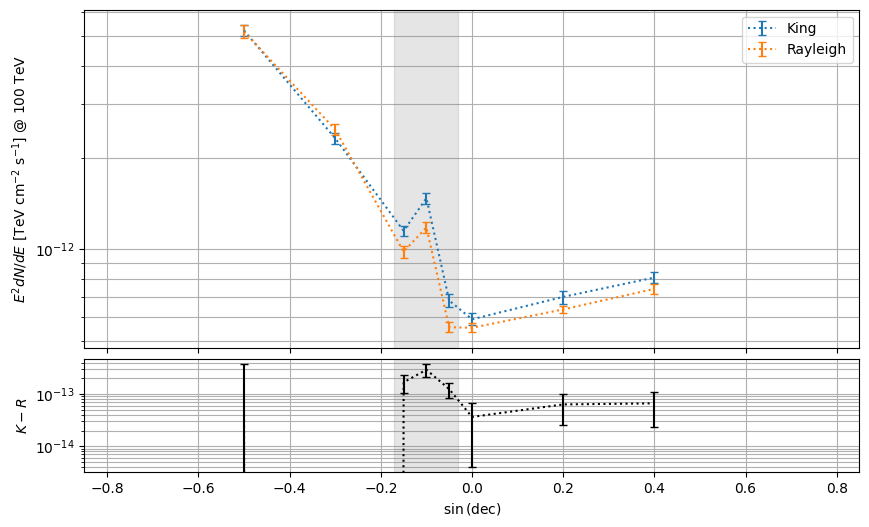

In [12]:
x = sorted(json_sens_dict.keys())

y = []
yerr = []
rayleigh_y = []
rayleigh_yerr = []

for k in x:
    d = json_sens_dict[k]
    tr = data_dict[k]["tr"]
    sens = d["n_sig"]

    rayleigh_d = rayleigh_sens_dict[k]
    rayleigh_sens = rayleigh_d["n_sig"]

    # percent → absolute error
    n_err = sens * d["n_sig_error"]
    rayleigh_n_err = rayleigh_sens * rayleigh_d["n_sig_error"]

    # central value
    flux = tr.to_E2dNdE(sens, E0=100, unit=1e3)
    rayleigh_flux = tr.to_E2dNdE(rayleigh_sens, E0=100, unit=1e3)

    # propagated error
    flux_err = tr.to_E2dNdE(sens + n_err, E0=100, unit=1e3) - flux
    rayleigh_flux_err = (
        tr.to_E2dNdE(rayleigh_sens + rayleigh_n_err, E0=100, unit=1e3)
        - rayleigh_flux
    )

    y.append(flux)
    yerr.append(flux_err)

    rayleigh_y.append(rayleigh_flux)
    rayleigh_yerr.append(rayleigh_flux_err)

# --- arrays ---
x = np.asarray(x)
y = np.asarray(y)
yerr = np.asarray(yerr)

rayleigh_y = np.asarray(rayleigh_y)
rayleigh_yerr = np.asarray(rayleigh_yerr)

# relative difference
absdiff = (y - rayleigh_y)

# error propagation
absdiff_err = np.sqrt(yerr**2 + rayleigh_yerr**2)

# --- plotting ---
fig, (ax, ax_diff) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

# top panel
ax.set_yscale("log")

ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax.errorbar(
    x,
    y,
    yerr=yerr,
    ls = 'dotted',
    marker = '',
    capsize=3,
    zorder=3,
    label="King",
)

ax.errorbar(
    x,
    rayleigh_y,
    yerr=rayleigh_yerr,
    ls="dotted",
    capsize=3,
    zorder=3,
    label="Rayleigh",
)

ax.legend()
ax.set_xlim(-0.85, 0.85)

ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)

# bottom panel
ax_diff.axhline(0, color="black", lw=1, ls="--")

ax_diff.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)

ax_diff.errorbar(
    x,
    absdiff,
    yerr=absdiff_err,
    ls="dotted",
    capsize=3,
    zorder=3,
    color = 'black'
)

ax_diff.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax_diff.set_ylabel(r"$K - R$")

ax_diff.grid(which="both", zorder=1)
ax_diff.set_yscale('log')
outpath = os.path.join(plot_dir, "sensitivity_flux_summary.png")

plt.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()

In [18]:
print(y)
print(rayleigh_y)

[5.21538791e-12 2.31166269e-12 1.15025495e-12 1.47136605e-12
 6.79676059e-13 5.89942999e-13 6.98731149e-13 8.08466218e-13]
[5.17450238e-12 2.46952689e-12 9.82972168e-13 1.18028761e-12
 5.55812325e-13 5.53529166e-13 6.35551279e-13 7.42230845e-13]


In [ ]:
for sin_dec, d in sorted(data_dict.items()):
    trial_runner: cy.trial.TrialRunner = d["tr"]
    bkg = d["bg"]
    with time('ps discovery potential'):
        print(f'Estimating discovery potential for sin(dec) = {sin_dec}')
        disc = trial_runner.find_n_sig(
        bkg.isf_nsigma(5), # p = 5 sigma
        0.5, # beta = 50%
        n_sig_step=5, 
        batch_size=500, 
        tol=.05)
        d["disc"] = disc

: 

: 

In [ ]:
disc_dict = {k: v["disc"] for k, v in data_dict.items()}

: 

: 

In [ ]:
json_disc_dict = to_jsonable(disc_dict)
with open(os.path.join(plot_dir, 'discovery_potential.json'), "w") as f:
    json.dump(json_disc_dict, f)

: 

: 

In [ ]:
x = sorted(data_dict.keys())

y = []
yerr = []

for k in x:
    d = data_dict[k]
    tr = d["tr"]

    disc = d["disc"]["n_sig"]

    # use /100 if n_sig_error is stored as percent like 5.3
    n_err = disc * d["disc"]["n_sig_error"] 

    flux = tr.to_E2dNdE(disc, E0=100, unit=1e3)
    flux_err = tr.to_E2dNdE(disc + n_err, E0=100, unit=1e3) - flux

    y.append(flux)
    yerr.append(flux_err)

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=3)
plt.xlabel("sin(dec)")
plt.ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
plt.yscale("log")
plt.grid()
outpath = os.path.join(plot_dir, f"discovery_potential_flux_summary.png")
plt.savefig(outpath, dpi=200)
plt.show()

: 

: 

## 3. Test for Bias

One powerful test of analysis readiness is to demonstrate that we can properly fit the parameters of an injected signal. For this we start by getting some batches of signal trials:

In [ ]:
n_sigs = np.r_[:101:10]
with time('ps fit bias trials'):
    for sin_dec, data in data_dict.items():
        trials = [get_many_fits_from_trials(tr = data["tr"],
                                            n_trials= 100, 
                                            n_sig=n_sig, 
                                            logging=True, 
                                            mp_cpus = 32,
                                            seed=int(n_sig)) for n_sig in n_sigs]
        
        #We add the true number of events injected for bookkeeping convenience:
        for (n_sig, t) in zip(n_sigs, trials):
            t['ntrue'] = np.repeat(n_sig, len(t))

        #Concatenate the trial batches:
        allt = cy.utils.Arrays.concatenate(trials)
        data_dict[sin_dec]['allt'] = allt

Performing 100 trials with n_sig=0 using 32 cores:


100/100 done
Performing 100 trials with n_sig=10 using 32 cores:
100/100 done
Performing 100 trials with n_sig=20 using 32 cores:
100/100 done
Performing 100 trials with n_sig=30 using 32 cores:
100/100 done
Performing 100 trials with n_sig=40 using 32 cores:
100/100 done
Performing 100 trials with n_sig=50 using 32 cores:
100/100 done
Performing 100 trials with n_sig=60 using 32 cores:
100/100 done
Performing 100 trials with n_sig=70 using 32 cores:
100/100 done
Performing 100 trials with n_sig=80 using 32 cores:
100/100 done
Performing 100 trials with n_sig=90 using 32 cores:
100/100 done
Performing 100 trials with n_sig=100 using 32 cores:
100/100 done
Performing 100 trials with n_sig=0 using 32 cores:
100/100 done
Performing 100 trials with n_sig=10 using 32 cores:
100/100 done
Performing 100 trials with n_sig=20 using 32 cores:
100/100 done
Performing 100 trials with n_sig=30 using 32 cores:
0/100

Plots:

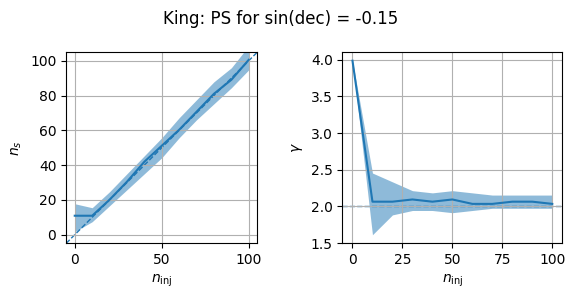

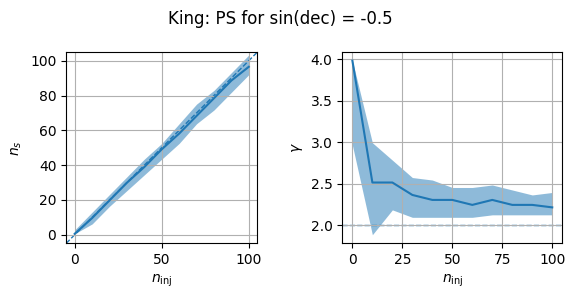

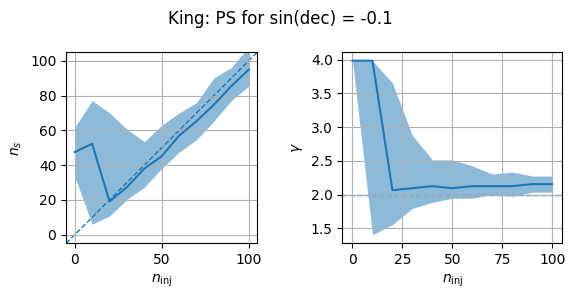

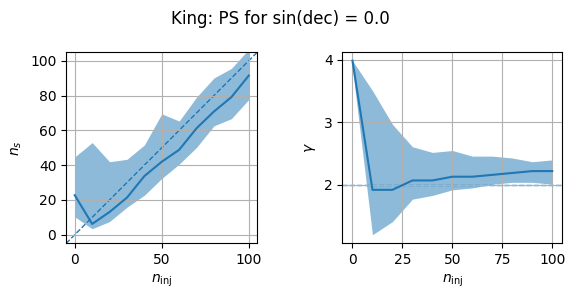

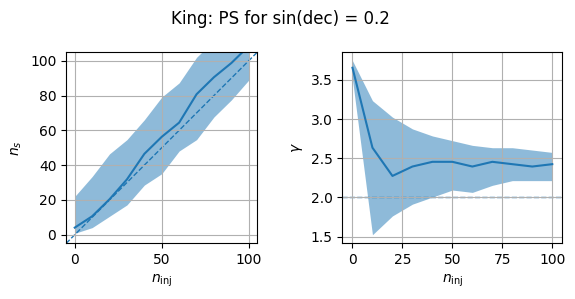

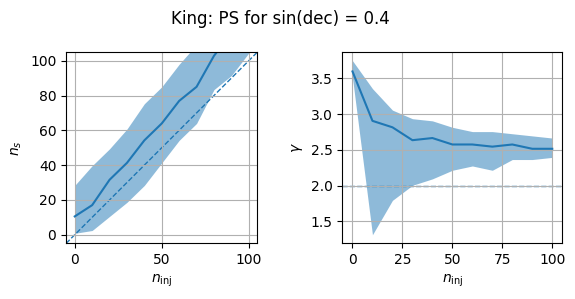

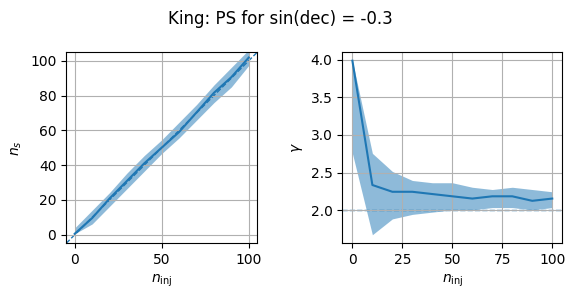

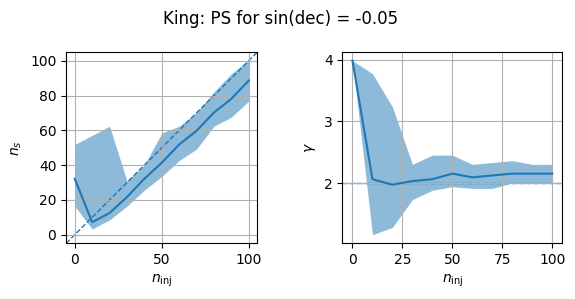

: 

In [ ]:
for sin_dec, data in data_dict.items():
    tr = data['tr']
    allt = data['allt']
    
    fig, axs = plt.subplots(1, 2, figsize=(6,3))

    dns = np.mean(np.diff(n_sigs))
    ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
    expect_kw = dict(color='C0', ls='--', lw=1, zorder=-10)
    expect_gamma = tr.sig_injs[0].flux[0].gamma

    ax = axs[0]
    h = hl.hist((allt.ntrue, allt.ns), bins=(ns_bins, 100))
    hl.plot1d(ax, h.contain_project(1),errorbands=True, drawstyle='default')

    lim = ns_bins[[0, -1]]
    ax.set_xlim(ax.set_ylim(lim))
    ax.plot(lim, lim, **expect_kw)
    ax.set_aspect('equal')


    ax = axs[1]
    h = hl.hist((allt.ntrue, allt.gamma), bins=(ns_bins, 100))
    hl.plot1d(ax, h.contain_project(1),errorbands=True, drawstyle='default')
    ax.axhline(expect_gamma, **expect_kw)
    ax.set_xlim(axs[0].get_xlim())

    for ax in axs:
        ax.set_xlabel(r'$n_\text{inj}$')
        ax.grid()
    axs[0].set_ylabel(r'$n_s$')
    axs[1].set_ylabel(r'$\gamma$')
    plt.suptitle(f'King: PS for sin(dec) = {sin_dec}')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"ps_king_sindec{sin_dec}.pdf"))

In [ ]:
for sin_dec, data in data_dict.items():

    tr = data["tr"]
    allt = data["allt"]

    dns = np.mean(np.diff(n_sigs))
    ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
    expect_gamma = tr.sig_injs[0].flux[0].gamma

    out = os.path.join(plot_dir, f"ps_king_sindec{sin_dec}.npz")

    np.savez(
        out,
        sin_dec=sin_dec,
        ntrue=np.asarray(allt.ntrue),
        ns=np.asarray(allt.ns),
        gamma=np.asarray(allt.gamma),
        n_sigs=np.asarray(n_sigs),
        ns_bins=np.asarray(ns_bins),
        expect_gamma=expect_gamma,
    )

: 

load PS from rayleigh, king for comparison

In [ ]:
king_dir = Path(plot_dir)

king_files = sorted(king_dir.glob("ps_king_sindec*.npz"))

ps_king_data = {}

for f in king_files:
    d = np.load(f)

    sin_dec = float(d["sin_dec"])

    ps_king_data[sin_dec] = {
        "ntrue": d["ntrue"],
        "ns": d["ns"],
        "gamma": d["gamma"],
        "ns_bins": d["ns_bins"],
        "expect_gamma": float(d["expect_gamma"]),
    }

print(ps_king_data.keys())

dict_keys([-0.05, -0.1, -0.15, -0.3, -0.5, 0.0, 0.2, 0.4])


: 

In [ ]:

rayleigh_dir = Path("/data/user/fkrafft/csky_gfu_tests/trials_100k_post2018/plots")

rayleigh_files = sorted(rayleigh_dir.glob("ps_rayleigh_sindec*.npz"))

ps_rayleigh_data = {}

for f in rayleigh_files:
    d = np.load(f)

    sin_dec = float(d["sin_dec"])

    ps_rayleigh_data[sin_dec] = {
        "ntrue": d["ntrue"],
        "ns": d["ns"],
        "gamma": d["gamma"],
        "ns_bins": d["ns_bins"],
        "expect_gamma": float(d["expect_gamma"]),
    }

print(ps_rayleigh_data.keys())

dict_keys([-0.05, -0.1, -0.15, -0.2, -0.3, -0.5, 0.0, 0.2, 0.4])


: 

In [ ]:
def plot_king_vs_rayleigh(ps_king_data, ps_rayleigh_data, plot_dir=None):
    matching_sindecs = sorted(set(ps_king_data) & set(ps_rayleigh_data))

    for sin_dec in matching_sindecs:
        king = ps_king_data[sin_dec]
        ray = ps_rayleigh_data[sin_dec]

        fig, axs = plt.subplots(
            2, 2,
            figsize=(7, 5),
            sharex="col",
            gridspec_kw={"height_ratios": [3, 1]},
        )

        # ---------- n_s plot ----------
        ax = axs[0, 0]
        rax = axs[1, 0]

        h_king = hl.hist(
            (king["ntrue"], king["ns"]),
            bins=(king["ns_bins"], 100),
        ).contain_project(1)

        h_ray = hl.hist(
            (ray["ntrue"], ray["ns"]),
            bins=(ray["ns_bins"], 100),
        ).contain_project(1)

        hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
        hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

        x_ns = h_king.centers[0]

        # reference line: y = x
        king_dev = h_king.values - x_ns
        ray_dev  = h_ray.values - x_ns

        rax.axhline(0, color="k", lw=1)
        rax.plot(x_ns, king_dev, drawstyle="steps-mid", label="King")
        rax.plot(x_ns, ray_dev, drawstyle="steps-mid", label="Rayleigh")

        lim = king["ns_bins"][[0, -1]]
        ax.plot(lim, lim, color="grey", ls="--", lw=1, zorder=-10)

        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_aspect("equal")

        ax.set_ylabel(r"$n_s$")
        rax.set_ylabel(r"$n_s - n_\mathrm{inj}$")
        rax.set_xlabel(r"$n_\text{inj}$")
        # ---------- gamma plot ----------
        ax = axs[0, 1]
        rax = axs[1, 1]

        h_king = hl.hist(
            (king["ntrue"], king["gamma"]),
            bins=(king["ns_bins"], 100),
        ).contain_project(1)

        h_ray = hl.hist(
            (ray["ntrue"], ray["gamma"]),
            bins=(ray["ns_bins"], 100),
        ).contain_project(1)

        hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
        hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

        x_gamma = h_king.centers[0]

        # reference line: gamma = expect_gamma
        gamma_ref = king["expect_gamma"]

        king_dev = h_king.values - gamma_ref
        ray_dev  = h_ray.values - gamma_ref

        rax.axhline(0, color="k", lw=1)
        rax.plot(x_gamma, king_dev, drawstyle="steps-mid", label="King")
        rax.plot(x_gamma, ray_dev, drawstyle="steps-mid", label="Rayleigh")

        ax.axhline(gamma_ref, color="grey", ls="--", lw=1, zorder=-10)
        ax.set_xlim(axs[0, 0].get_xlim())

        ax.set_ylabel(r"$\gamma$")
        rax.set_ylabel(r"$\gamma - \gamma_\mathrm{exp}$")
        rax.set_xlabel(r"$n_\text{inj}$")

        for ax in axs.flat:
            ax.grid()
        axs[0, 0].legend()

        fig.suptitle(f"PS comparison for sin(dec) = {sin_dec}")
        fig.tight_layout()

        if plot_dir is not None:
            fig.savefig(
                f"{plot_dir}/ps_king_vs_rayleigh_sindec{sin_dec}.pdf"
            )

        plt.show()

: 

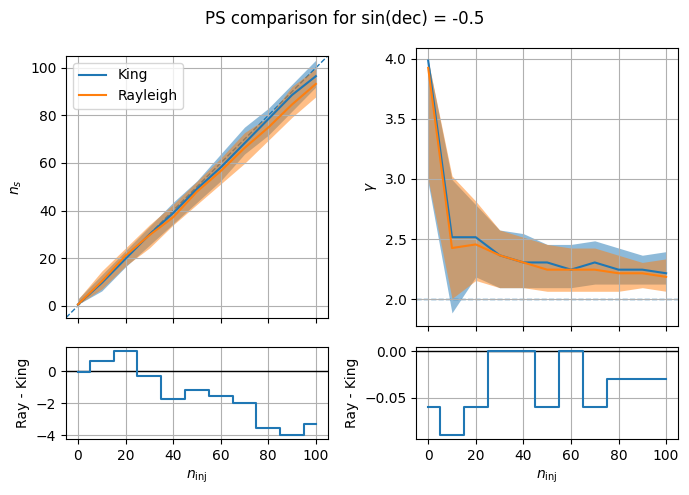

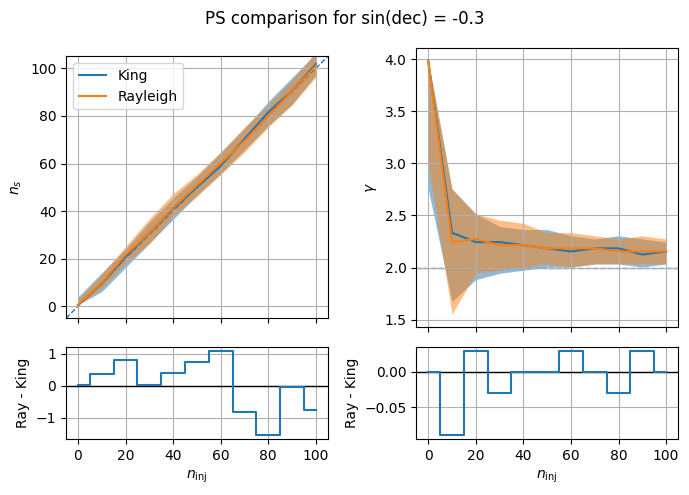

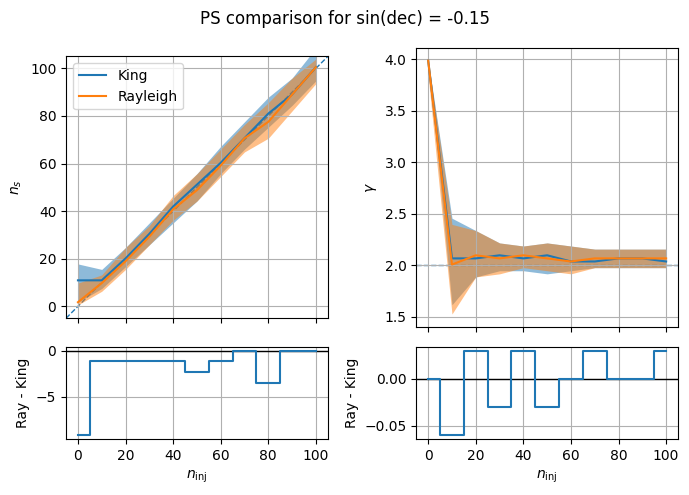

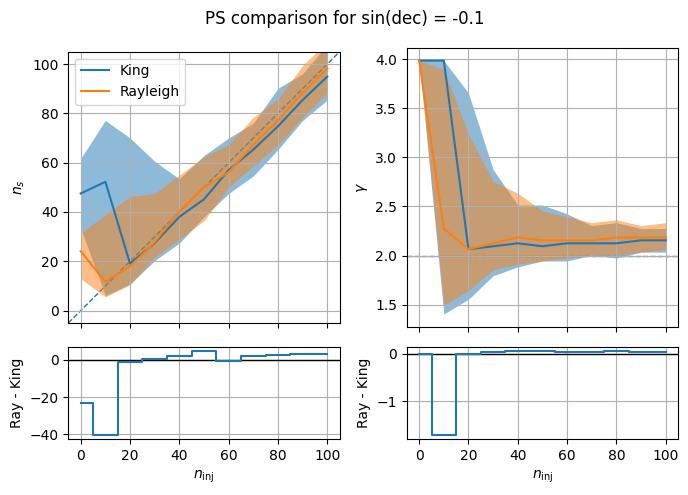

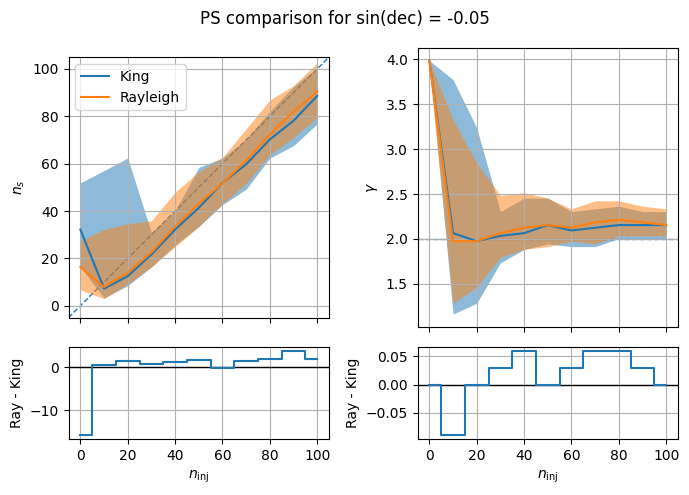

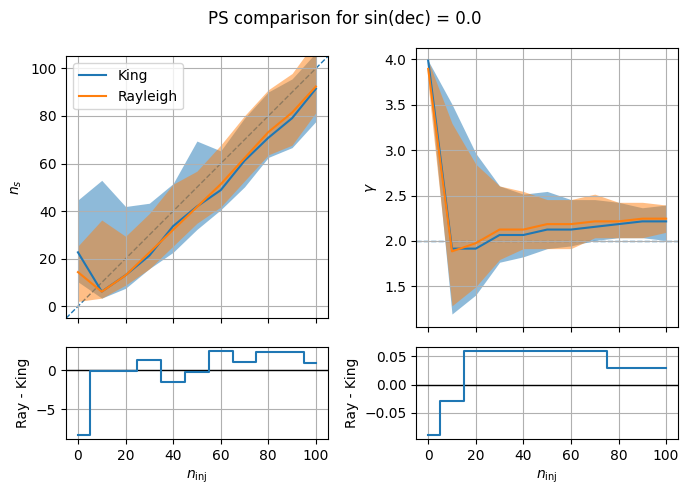

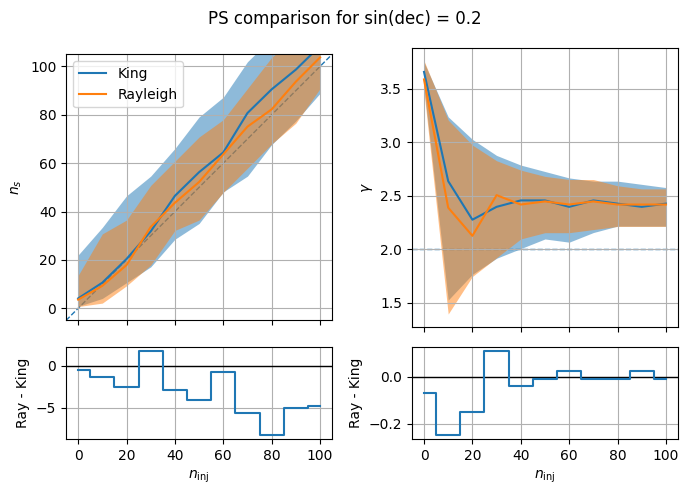

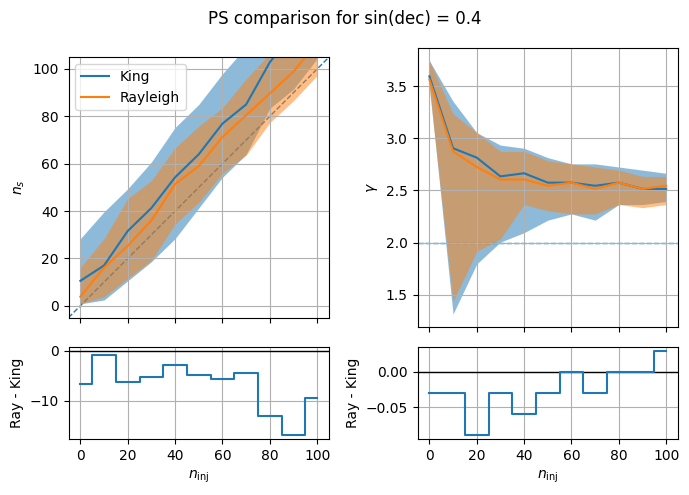

: 

In [ ]:
plot_king_vs_rayleigh(ps_king_data, ps_rayleigh_data, plot_dir=plot_dir)

: 